In [1]:
import numpy as np
import pandas as pd

from geopy.geocoders import Nominatim

from math import radians, cos, sin, asin, sqrt
import googlemaps
from datetime import datetime

import random

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# Cleaning Data

In [10]:
yerevan_actual_raw = pd.read_csv('../database/raw_data/Yerevan actual.csv')

## filtering out duplicated in id 

In [11]:
yerevan_actual_raw = yerevan_actual_raw.drop(["OBJECTID", "level_0", "index"], axis = 1)
duplicates = yerevan_actual_raw.duplicated(subset=['id'])
yerevan_actual = yerevan_actual_raw[~duplicates].drop_duplicates(subset=['id'])
yerevan_actual = yerevan_actual.reset_index()

In [20]:
test1 = yerevan_actual[(yerevan_actual['rent_or_sale']=='sale appartments') | (yerevan_actual['rent_or_sale']=='sale houses')]

## Ceategorizing Regions

In [ ]:
data = yerevan_actual.copy()

In [ ]:
geolocator = Nominatim(user_agent="my_application")

count = 0
yerevan_districts = pd.DataFrame(columns=['x', 'y', 'district'])

import pandas as pd

# Create an empty DataFrame to store the results


def get_district(lat, lng):
    # Reverse geocode the coordinates to get the address
    location = geolocator.reverse(f"{lat}, {lng}", timeout=None)
    # Extract the district information from the address
    address = location.raw['address']
    district = address.get('suburb', address.get('city_district'))
    return district


In [ ]:
# Loop through each row of the data and calculate the district for each row
for i, row in data.iterrows():
    # Calculate the district for the current row
    district = get_district(row['x'], row['y'])
    count = count + 1
    data.drop(index=data.index[0], axis=0, inplace=True)
    # Append the current row to the new DataFrame
    yerevan_districts = yerevan_districts.append({'x': row['x'], 'y': row['y'], 'district': district}, ignore_index=True)

In [ ]:
# Save the results to a CSV file
yerevan_actual["district"] = yerevan_districts["district"]
# yerevan_actual.to_csv("../database/yerevan_actual_clean/Yerevan.csv", index=False)

In [26]:
yerevan_actual.to_csv('../database/yerevan_actual_clean/Yerevan.csv')

# outlier detection

In [2]:
yerevan_actual = pd.read_csv('../database/yerevan_actual_clean/Yerevan.csv')

In [3]:
# house_filtered = yerevan_actual.dropna()
houses_filt = yerevan_actual.dropna(subset=['price'])

In [4]:
# price null values are gone
sale = houses_filt.loc[(houses_filt["rent_or_sale"]=="sale appartments") | (houses_filt["rent_or_sale"]=="sale houses")]
rent = houses_filt.loc[(houses_filt["rent_or_sale"]=="rent houses") | (houses_filt["rent_or_sale"]=="rent appartments")]
# all null values are gone
# sale = house_filtered.loc[(house_filtered["rent_or_sale"]=="sale appartments") | (house_filtered["rent_or_sale"]=="sale houses")]
# rent = house_filtered.loc[(house_filtered["rent_or_sale"]=="rent houses") | (house_filtered["rent_or_sale"]=="rent appartments")]

In [6]:
armenian_to_english = {'Աջափնյակ': 'Achapnyak',
                       'Նոր Նորք': 'Nor_Nork',
                       'Արաբկիր': 'Arabkir',
                       'Կենտրոն': 'Kentron',
                       'Դավթաշեն': 'Davtashen',
                       'Էրեբունի': 'Erebuni',
                       'Շենգավիթ': 'Shengavit',
                       'Քանաքեռ-Զեյթուն': 'Qanaqer_Zeytun',
                       'Մալաթիա-Սեբաստիա': 'Malatia_Sebastia',
                       'Ավան': 'Avan',
                       'Նոր Նորքի 1-ին զանգված': 'Nor_Nork',
                       'Նոր Նորքի 2-րդ զանգված': 'Nor_Nork',
                       'Դավթաշեն գյուղ': 'Davtashen',
                       'Նորք Մարաշ': 'Norq_Marash',
                       'Գլենդել Հիլզ': 'Kentron',
                       'Նուբարաշեն': 'Nubarashen',
                       'Հաղթանակ': 'Malatia_Sebastia',
                       'Նոյ թաղամաս': 'Malatia_Sebastia',
                       'Մուշ թաղամաս': 'Malatia_Sebastia',
                       'Էկո քաղաք': 'Achapnyak'}

sale['district'] = sale['district'].replace(armenian_to_english)

### Box-Plot


(0.0, 2000000.0)

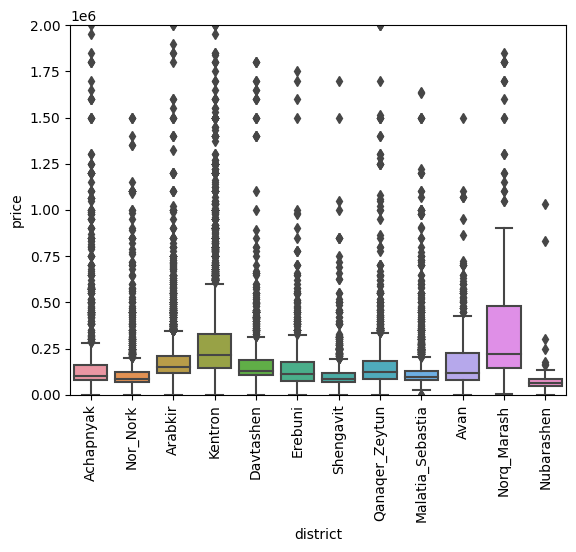

In [7]:
sns.boxplot(x='district', y='price', data=sale)
plt.xticks(rotation=90)
plt.ylim(0, 2000000)

### Z-Score


In [ ]:
# from scipy import stats

# # read in the data
# #df = pd.read_csv('data.csv')

# # group the data by district
# grouped_data = sale_copy.groupby('district')

# # loop over each group and calculate the Z-score for price
# for name, group in grouped_data:
#    # print(group["district"])
#     z = np.abs(stats.zscore(group['price']))
#     #print(z)
#     threshold = 3
#     outliers = group[z > threshold]
    
#     num_outliers = len(outliers)
#     print(f"District {name} has {num_outliers} outliers")
#     sale_copy = sale_copy.drop(outliers.index)

In [14]:
sale['square_meters'] = sale['square_meters'].replace(0, None)
sale['square_meters'] = sale['square_meters'].astype(float)


for index, row in sale.iterrows():
    if np.isnan(row['price_per_meter']):
        continue
    else:
        sale.loc[index, 'square_meters'] = row['price'] / row['price_per_meter']
        
for index, row in sale.iterrows():
    if np.isnan(row['square_meters']):
        continue
    else:
        sale.loc[index, 'price_per_meter'] = row['price'] / row['square_meters']

### IQR


In [16]:
grouped_data = sale.groupby('district')

for name, group in grouped_data:
    q1 = group['price'].quantile(0.25)
    #print(q1)
    q3 = group['price'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = max(q1 - 1.5 * iqr, 5000)
    # print(lower_bound)
    upper_bound = q3 + 1.5 * iqr
    outliers = group[(group['price'] < lower_bound) | (group['price'] > upper_bound)]
    num_outliers = len(outliers)
    print(f"District {name} has {num_outliers} outliers")
    sale = sale.drop(outliers.index)

# group data for new sale after IQR ran on price
grouped_data = sale.groupby('district')

for name, group in grouped_data:
    q1 = group['square_meters'].quantile(0.25)
    #print(q1)
    q3 = group['square_meters'].quantile(0.75)
    iqr = q3 - q1
    lower_bound =  max(q1 - 1.5 * iqr, 40)
    upper_bound = q3 + 1.5 * iqr
    outliers = group[(group['square_meters'] < lower_bound) | (group['square_meters'] > upper_bound)]
    num_outliers = len(outliers)
    print(f"District {name} has {num_outliers} outliers")
    sale = sale.drop(outliers.index)

District Achapnyak has 207 outliers
District Arabkir has 384 outliers
District Avan has 59 outliers
District Davtashen has 136 outliers
District Erebuni has 79 outliers
District Kentron has 458 outliers
District Malatia_Sebastia has 224 outliers
District Nor_Nork has 181 outliers
District Norq_Marash has 29 outliers
District Nubarashen has 9 outliers
District Qanaqer_Zeytun has 142 outliers
District Shengavit has 120 outliers
District Achapnyak has 220 outliers
District Arabkir has 323 outliers
District Avan has 61 outliers
District Davtashen has 137 outliers
District Erebuni has 114 outliers
District Kentron has 676 outliers
District Malatia_Sebastia has 229 outliers
District Nor_Nork has 150 outliers
District Norq_Marash has 6 outliers
District Nubarashen has 5 outliers
District Qanaqer_Zeytun has 197 outliers
District Shengavit has 328 outliers


### Mahalnobis Distance

In [ ]:
# from sklearn.covariance import MinCovDet
# from scipy.spatial.distance import mahalanobis

# # loop over each group and calculate the Mahalanobis distance
# dfs_to_concat = []
# grouped_data = sale.groupby('district')
# for name, group in grouped_data:
#     X = group[['price', 'square_meters']]
#     covariance = np.cov(X, rowvar=False)
#     mahal = np.apply_along_axis(lambda x: mahalanobis(x, X.mean(axis=0), np.linalg.inv(covariance)), 1, X)
#     threshold = 3
#     outliers = group[np.array(mahal) > threshold]
#     num_outliers = len(outliers)
#     print(f"District {name} has {num_outliers} outliers:")
#     #print(outliers)
# #     filtered_group = group[np.array(mahal) <= threshold]
# #     dfs_to_concat.append(filtered_group)

# # # concatenate the filtered DataFrames back together
# # filtered_df = pd.concat(dfs_to_concat, ignore_index=True)

In [17]:
sale.drop(columns=['index'], inplace=True)
sale = sale.rename(columns={'date': 'download_date'})

## Metro Distance Calculation

In [ ]:
sale = pd.read_excel('../database/yerevan_actual_clean/Yerevan.xlsx')
houses = sale.copy() # houses is used for testing

# Load the houses and stations tables into pandas dataframes

stations = pd.DataFrame({
    'station_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'station_name': ['Barekamutyun', 'Baghramyan', 'Yeritasardakan', 'Republic Square', 'Zoravar Andranik', 'Sasuntsi Davit', 'Gortsaranain','Shengavit', 'Charbakh', 'Garegin Nzhdeh Square'],
    'x': [40.197446,40.1918167,40.1873081, 40.1785331, 40.1699272, 40.1552243, 40.1410611, 40.145224, 40.1405941, 40.1504761],
    'y': [44.493467,44.5038091, 44.5191743, 44.5134433, 44.5112603, 44.5058011, 44.4964173, 44.48483, 44.4685333, 44.4816183]
})

In [ ]:
# Define a function to calculate the Haversine distance between two points
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # Convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # Haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r

def get_walking_distance(start_lon, start_lat, end_lon, end_lat):
    # Set up the Google Maps API client
    gmaps = googlemaps.Client(key='***REMOVED-GOOGLE-API-KEY***')

    # Define the start and end coordinates
    start = (start_lat, start_lon)
    end = (end_lat, end_lon)

    # Make the API request
    now = datetime.now()
    directions = gmaps.directions(start, end, mode='walking', departure_time=now)

    # Extract the distance from the response
    distance = directions[0]['legs'][0]['distance']['value']

    # Return the distance in meters
    return distance

#### calculating distance from every house to every metro station and taking shortest path

In [ ]:
# Loop through each house and station to find the shortest distance using Haversine
distances = []
station_ids = []
station_names = []
for house_idx, house in houses.iterrows():
    shortest_distance = float('inf')
    nearest_station_name = ''
    for station_idx, station in stations.iterrows():
        distance = haversine(house['y'], house['x'], station['y'], station['x'])
        if distance < shortest_distance:
            shortest_distance = distance
            nearest_station_id = station['station_id']
            nearest_station_name = station['station_name']
    #distances.append(shortest_distance)
    station_ids.append(nearest_station_id)
    station_names.append(nearest_station_name)

# Add the new columns to the houses table
#houses['shortest_distance'] = distances
houses['nearest_station_id'] = station_ids
houses['nearest_station_name'] = station_names
houses

#### we have closest metro station using haversine distance, now we calculate the walking distance
The code runs for around 4-5 hours so it is commented out

In [19]:
sale["closest_metro"] = houses["nearest_station_name"]
distances = []

# Using Google Maps API to calculate the walking distance
for i, house in houses.iterrows():
    distance = get_walking_distance(house['y'], house['x'], stations['y'][house['nearest_station_id']-1], stations['x'][house['nearest_station_id']-1])
    distances.append(distance)
    houses.drop(index=houses.index[0], axis=0, inplace=True)
#houses["walk_distance"] = distances

sale["walking_distance_to_metro(m)"] = distances

# Overwriting Yervan.xlsx file with the new metro and walking distance columns
sale.to_csv("../database/yerevan_actual_clean/Yerevan.csv", index=False)

## Spatial Jittering


In [18]:
def apply_jitter(coord, distance):
    """
    Apply jitter to a coordinate (latitude or longitude).

    :param coord: Input coordinate (float)
    :param distance: Maximum distance to apply jitter (float)
    :return: jittered_coord: Jittered coordinate (float)
    """
    jittered_coord = coord + (distance * random.uniform(-1, 1))
    return jittered_coord

In [19]:
jitter_distance = 0.00001  # Adjust this value according to the desired jitter distance
sale['latitude_jittered'] = sale['y'].apply(lambda x: apply_jitter(x, jitter_distance))
sale['longitude_jittered'] = sale['x'].apply(lambda x: apply_jitter(x, jitter_distance))
grouped_data = sale.groupby(['latitude_jittered', 'longitude_jittered']).size().reset_index(name='count')

sorted_grouped_data = grouped_data.sort_values('count', ascending=False)

most_frequent_coords = sorted_grouped_data.head()
print(most_frequent_coords)

       latitude_jittered  longitude_jittered  count
0              44.409840           40.164128      1
12528          44.516445           40.150502      1
12544          44.516454           40.140363      1
12543          44.516453           40.150494      1
12542          44.516453           40.150508      1


In [23]:
sale.drop(columns=['Unnamed: 0'], inplace=True)

In [24]:
sale.to_csv("../database/yerevan_actual_clean/sale_actual.csv", index=False)